In [1]:
import sys

sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

from tfds.plotting import prettify, use_tex

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from trading_information.mechanism import Mechanism
from trading_information.hyperopt import HyperOpt, HyperOptVirtuals
from trading_information.distributions import Uniform, BetaMixture
from trading_information.virtual_values import VirtualValues

from tqdm import tqdm
import matplotlib as mpl
import matplotlib.cm as cm

use_tex()

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


/Library/TeX/texbin/latex


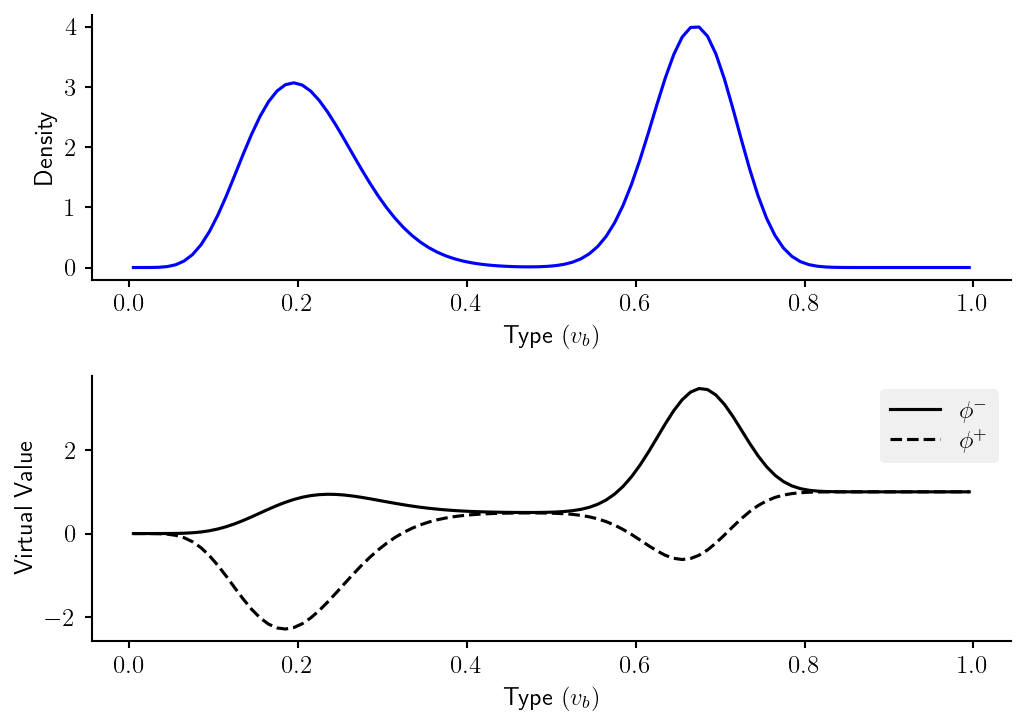

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

num_intervals = 100
tau = 0
prob_state0 = 0.5
dist = BetaMixture(alphas=(8, 60), betas=(30, 30), weights=(0.5, 0.5))  # bimodal

mechanism = Mechanism(num_intervals=num_intervals, dist=dist)
midpoints = mechanism.midpoints

fig, axs = plt.subplots(2, 1, figsize=(7, 5), dpi=150)

ax = axs[0]
ax.plot(midpoints, mechanism._pdfs, color="blue")
ax.set_xlabel("Type $(v_b)$")
ax.set_ylabel("Density")
prettify(ax=ax)


virtual_values = VirtualValues(dist=dist, types=midpoints, tau=tau, prob_state0=prob_state0, iron=False)
virtual_values_ironed = VirtualValues(dist=dist, types=midpoints, tau=tau, prob_state0=prob_state0, iron=True)

ax = axs[1]

alpha = 1
ax.plot(midpoints, virtual_values.negative, color="k", label=r"$\phi^-$", alpha=alpha)
ax.plot(midpoints, virtual_values.positive, color="k", label=r"$\phi^+$", ls="dashed", alpha=alpha)

# ax.plot(midpoints, virtual_values_ironed.negative, color="blue", ls="solid", label=r"$\phi$")
# ax.plot(midpoints, virtual_values_ironed.positive, color="blue", ls="dashed", label=r"$\phi$")

ax.set_xlabel("Type $(v_b)$")
ax.set_ylabel("Virtual Value")
prettify(ax=ax)




In [3]:
taus = [0, 1/3, 2/3, 1]
#taus = np.linspace(0, 1, 50)
num_taus = len(taus)
all_allocations = np.zeros((num_taus, num_intervals))
all_transfers = np.zeros((num_taus, num_intervals))
all_externalities = np.zeros((num_taus, num_intervals))
all_virtual_values_negative = np.zeros((num_taus, num_intervals))
all_virtual_values_positive = np.zeros((num_taus, num_intervals))

all_lagrangians = np.zeros(num_taus)

for i, tau in enumerate(tqdm(taus)):
    prob_state0 = 0

    dist = BetaMixture(alphas=(8, 60), betas=(30, 30), weights=(0.5, 0.5))  # bimodal
    #dist = Uniform(low=0, high=1)  # uniform

    mechanism = Mechanism(num_intervals=num_intervals, dist=dist)
    midpoints = mechanism.midpoints

    threshold_indices = np.arange(30, 80)
    hyperopt = HyperOpt(mechanism=mechanism, threshold_indices=threshold_indices)

    hyperopt.run(tau, prob_state0, desc="threshold")
    threshold_index = hyperopt.best()
    
    allocations, bins, avg_transfer, avg_externality, lag, obj = (
        mechanism.solve_with_increments(
            tau=tau,
            prob_state0=prob_state0,
            threshold_index=threshold_index,
            doprint=False,
            
        )
    )
    transfers = mechanism._allocations_to_transfers(allocations)
    externalities = mechanism._allocations_to_externalities(allocations, tau=tau, prob_state0=prob_state0)

    virtual_values = VirtualValues(
            dist=dist, types=midpoints, tau=tau, prob_state0=prob_state0, iron=True
        )

    all_allocations[i, :] = allocations
    all_transfers[i, :] = transfers
    all_externalities[i, :] = externalities

    all_virtual_values_negative[i, :] = virtual_values.negative
    all_virtual_values_positive[i, :] = virtual_values.positive
    all_lagrangians[i] = lag * num_intervals



100%|██████████| 4/4 [00:04<00:00,  1.03s/it]


In [4]:
all_allocations[0]

array([-1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -0.23684211, -0.23684211, -0.23684211,
       -0.23684211, -0.23684211, -0.23684211, -0.23684211, -0.23684211,
       -0.23684211, -0.23684211, -0.23684211, -0.23684211, -0.23684211,
       -0.23684211, -0.23684211, -0.23684211, -0.23684211, -0.23684211,
       -0.23684211, -0.23684211, -0.23684211, -0.23684211, -0.23684211,
       -0.23684211, -0.23684211, -0.23684211, -0.23684211, -0.23684211,
       -0.23684211, -0.23684211, -0.23684211, -0.23684211, -0.23684211,
       -0.23684211, -0.23684211, -0.23684211, -0.23684211, -0.23684211,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [5]:
all_allocations[1]

array([-1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -0.44736842, -0.44736842, -0.44736842,
       -0.44736842, -0.44736842, -0.44736842, -0.44736842, -0.44736842,
       -0.44736842, -0.44736842, -0.44736842, -0.44736842, -0.44736842,
       -0.44736842, -0.44736842, -0.44736842, -0.44736842, -0.44736842,
       -0.44736842, -0.44736842, -0.44736842, -0.44736842, -0.44736842,
       -0.44736842, -0.44736842, -0.44736842, -0.44736842, -0.44736842,
       -0.44736842, -0.44736842, -0.44736842, -0.44736842, -0.44736842,
       -0.44736842, -0.44736842, -0.44736842, -0.44736842, -0.44736842,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  1.        ,  1.        ,  1.  

In [6]:
all_allocations[3]

array([-1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -0.73684211, -0.73684211, -0.73684211,
       -0.73684211, -0.73684211, -0.73684211, -0.73684211, -0.73684211,
       -0.73684211, -0.73684211, -0.73684211, -0.73684211, -0.73684211,
       -0.73684211, -0.73684211, -0.73684211, -0.73684211, -0.73684211,
       -0.73684211, -0.73684211, -0.73684211, -0.73684211, -0.73684211,
       -0.73684211, -0.73684211, -0.73684211, -0.73684211, -0.73684211,
       -0.73684211, -0.73684211, -0.73684211, -0.73684211, -0.73684211,
       -0.73684211, -0.73684211, -0.73684211, -0.73684211, -0.73684211,
        1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
        1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
        1.        ,  1.        ,  1.        ,  1.        ,  1.  

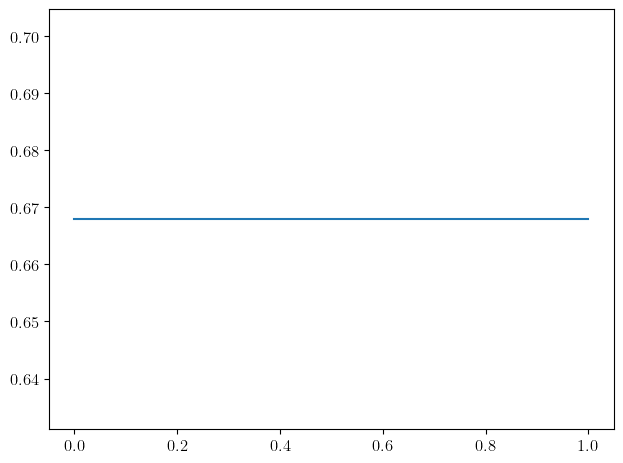

In [7]:
plt.plot(taus, all_lagrangians)

In [8]:
all_lagrangians

array([0.66798283, 0.66798283, 0.66798283, 0.66798283])

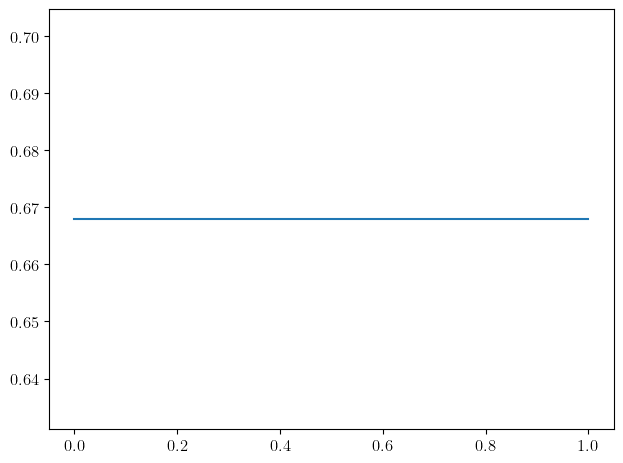

In [9]:
plt.plot(taus, all_lagrangians)

0.6679828347372806
0.6679828347372804
0.6679828347372805
0.6679828347372807


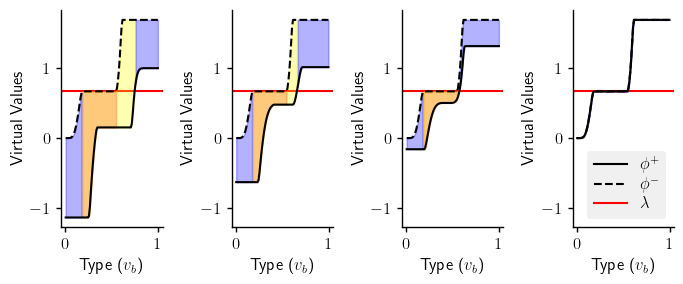

In [21]:
fig, axs = plt.subplots(1, 4, figsize=(7, 3), sharey=True)


for i, tau in enumerate(taus):
    ax = axs[i]
    pos, neg = all_virtual_values_positive[i],  all_virtual_values_negative[i]
    lag = all_lagrangians[i]    
    ax.plot(mechanism.midpoints, pos, color="k", label=r"$\phi^+$")
    ax.plot(mechanism.midpoints, neg, color="k", ls="dashed", label=r"$\phi^-$")
    ax.axhline(y=lag, color="red", ls="solid", zorder=0, label=r"$\lambda$")
    
    ax.set_xlabel("Type ($v_b$)")
    
    ax.set_ylabel("Virtual Values")

    mid = mechanism.midpoints

    ax.fill_between(mid, neg, pos, where=np.abs(neg - lag ) <= 1e-3, color="red", alpha=0.3)
    ax.fill_between(mid, neg, pos, where=np.abs(pos - lag ) <= 1e-3, color="red", alpha=0.3)




    ax.fill_between(mid, neg, pos, where=(neg > lag) & (pos <= lag), color="yellow", alpha=0.3)
    ax.fill_between(mid, neg, pos, where=(neg < lag), color="blue", alpha=0.3)
    ax.fill_between(mid, neg, pos, where=(pos > lag), color="blue", alpha=0.3)

    print(lag)

   

    prettify(ax=ax, legend=True if i == 3 else False, legend_loc="lower right")


#ax.arrow(0.1, 0.5, 0, -1, head_width=0.01, head_length=0.1, fc='k', ec='k')



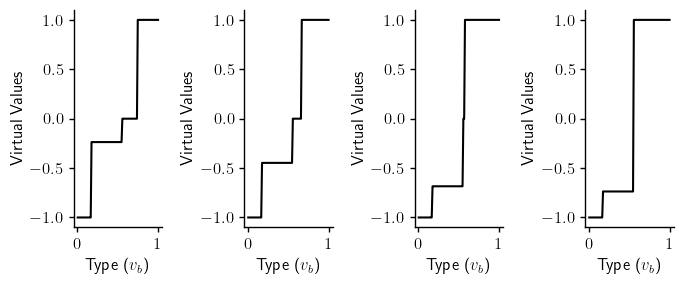

In [17]:
fig, axs = plt.subplots(1, 4, figsize=(7, 3), sharey=True)


for i, tau in enumerate(taus):
    ax = axs[i]
    alloc = all_allocations[i]

    ax.plot(mechanism.midpoints, alloc, color="k")
    ax.set_xlabel("Type ($v_b$)")

    ax.set_ylabel("Virtual Values")
    prettify(ax=ax, legend=False)


#ax.arrow(0.1, 0.5, 0, -1, head_width=0.01, head_length=0.1, fc='k', ec='k')



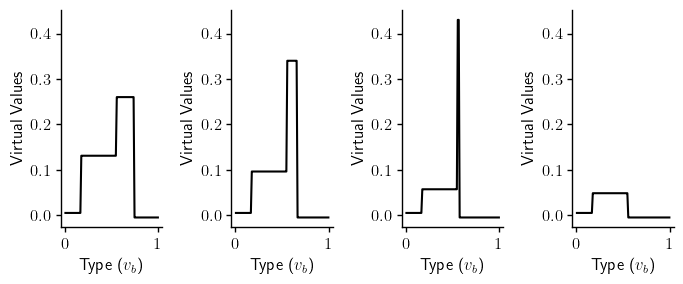

In [18]:
fig, axs = plt.subplots(1, 4, figsize=(7, 3), sharey=True)
for i, tau in enumerate(taus):
    ax = axs[i]
    alloc = all_transfers[i]

    ax.plot(mechanism.midpoints, alloc, color="k")
    ax.set_xlabel("Type ($v_b$)")

    ax.set_ylabel("Virtual Values")
    prettify(ax=ax, legend=False)


#ax.arrow(0.1, 0.5, 0, -1, head_width=0.01, head_length=0.1, fc='k', ec='k')



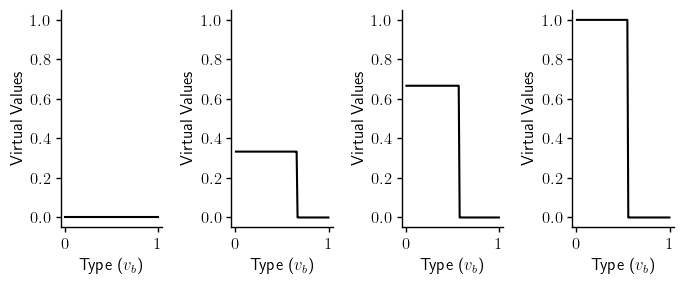

In [19]:
fig, axs = plt.subplots(1, 4, figsize=(7, 3), sharey=True)
for i, tau in enumerate(taus):
    ax = axs[i]
    alloc = all_externalities[i]

    ax.plot(mechanism.midpoints, alloc, color="k")
    ax.set_xlabel("Type ($v_b$)")

    ax.set_ylabel("Virtual Values")
    prettify(ax=ax, legend=False)


#ax.arrow(0.1, 0.5, 0, -1, head_width=0.01, head_length=0.1, fc='k', ec='k')

